# Predicting Player Subscription in PLAIcraft 

## Introduction 

A group of UBC computer science students, named The Pacific Laboratory for Artificial Intelligence (PLAI), are conducting research on player actions in their own MineCraft server, PLAIcraft. This is being done with hopes of developing an advanced AI tool, also known as embodied AI, to implement in the video game. Additionally, supporting the server requires adequate information about the amount and type of players for recruitment efforts. As such, data on players and their gameplay is being collected through this MineCraft server.  


**General question:**
What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?


**Predictive Question:** Does player age and number of sessions predict whether they will subscribe in a game-related newsletter?

To answer this question, we will use two files: players.csv and sessions.csv. Together, these datasets capture the characteristics and game behaviors on the PLAIcraft Minecraft Server. 

The players.csv dataset contains 196 observations with each row representing a unique player and includes seven variables describing player demographics and characteristics. 

These variables include: 
- **experience** (qualitative), which categorizes the player’s experience level across 5 levels 
- **subscribe** (qualitative), a TRUE / FALSE indicator of whether the player is subscribed to the news letter 
- **hashedEmail** (qualitative), a unique identifier for each player 
- **played_hours** (quantitative), a numeric value representing the total hours each player has spent on the server
- **name** (qualitative), the player’s displayed name
- **gender** (qualitative), recorded as one of 6 categories (Male, Female, Non-binary, Prefer not to say, Other, Two-Spirited) 
- **Age** (quantitative), a numeric value of the player’s age in years

The sessions.csv dataset contains essential behavioral data with 1,525 observations, with each row representing an individual playing session in the server. This means that a single player may appear multiple times in the dataset. The dataset includes five variables:

- **hashedEmail** (qualitative), a unique identifier for each player (same as players.csv)
- **start_time** (qualitative), the timestamp when the session began (date and time) 
- **end_time** (qualitative), the timestamp when the session ended (data and time)
- **original_start_time** (quantitative), raw unfiltered time stamp when the session began (epoch timestamp) 
- **original_end_time** (quantitative), raw unfiltered time stamp when the session ended (epoch timestamp)

To address our predictive question, we will combine the datasets into one using the shared hashedEmail identifier variable and then use the variables Age and session_count as the predictor variables, with subscribe as the response variable. Before combining the players.csv and sessions.csv datatsets, the session_count variable will be generated from the sessions.csv dataset by counting the total number of sessions associated with each player’s hashedEmail.

## Data Description

In [8]:
library(tidyverse)
library(tidymodels)
library(themis)
set.seed(1234)
players <- read_csv("https://raw.githubusercontent.com/chrispy-tacos/dsci-100-project/refs/heads/main/players.csv")
sessions <- read_csv("https://raw.githubusercontent.com/chrispy-tacos/dsci-100-project/refs/heads/main/sessions.csv")

sessions_compressed <- sessions |>
    select(hashedEmail) |>
    group_by(hashedEmail) |>
    summarize(session_count = n())

combined_data <- players |>
    inner_join(sessions_compressed)

head(combined_data)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Joining with `by = join_by(hashedEmail)`


experience,subscribe,hashedEmail,played_hours,name,gender,Age,session_count
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<int>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,27
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17,3
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17,1
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21,1
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21,1
Amateur,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21,1


## Summary statistics

We will now acquire relevant summary statistiscs for our analysis from the combined dataset created above. We would like to look at the median and mean of player age, as well as the mean number of sessions per player.

In [9]:
# summary of player ages
summary_age <- players |>
    mutate(avg_age = mean(Age, na.rm = TRUE), 
            med_age = median(Age, na.rm = TRUE)) |>
    select(avg_age, med_age) |>
    slice(1) |>
    mutate(avg_age = round(avg_age, 2))
summary_age

avg_age,med_age
<dbl>,<dbl>
21.14,19


**Table 1.** The average age is 21 years and the median age is 19.

In [10]:
# summary of player sessions
summary_session <- combined_data |>
        mutate(avg_session = mean(session_count), na.rm = TRUE) |>
        select(avg_session) |>
        slice(1) |>
        mutate(avg_session = round(avg_session, 2))
summary_session

avg_session
<dbl>
12.28


**Table 2.** The average number of sessions played per player was 12.

# Methods

## Determining the method for data analysis 

In [11]:
minecraft_clean<- combined_data|> 
drop_na(Age, session_count)

The data was cleaned to drop any NA values for the following steps. This makes the data have an equal amount of predictors for the bind_cols function that will be used to analyze the strength of our model. 

In [12]:
subscribe_count<- minecraft_clean|> 
count(subscribe)

subscribe_count

subscribe,n
<lgl>,<int>
FALSE,32
TRUE,91


**Table 3.** The above code checks the balance of the data. From the table we can see that the TRUE label is overrepresented in the data set (3:1 ratio) and therefore there is an imbalance in the data.

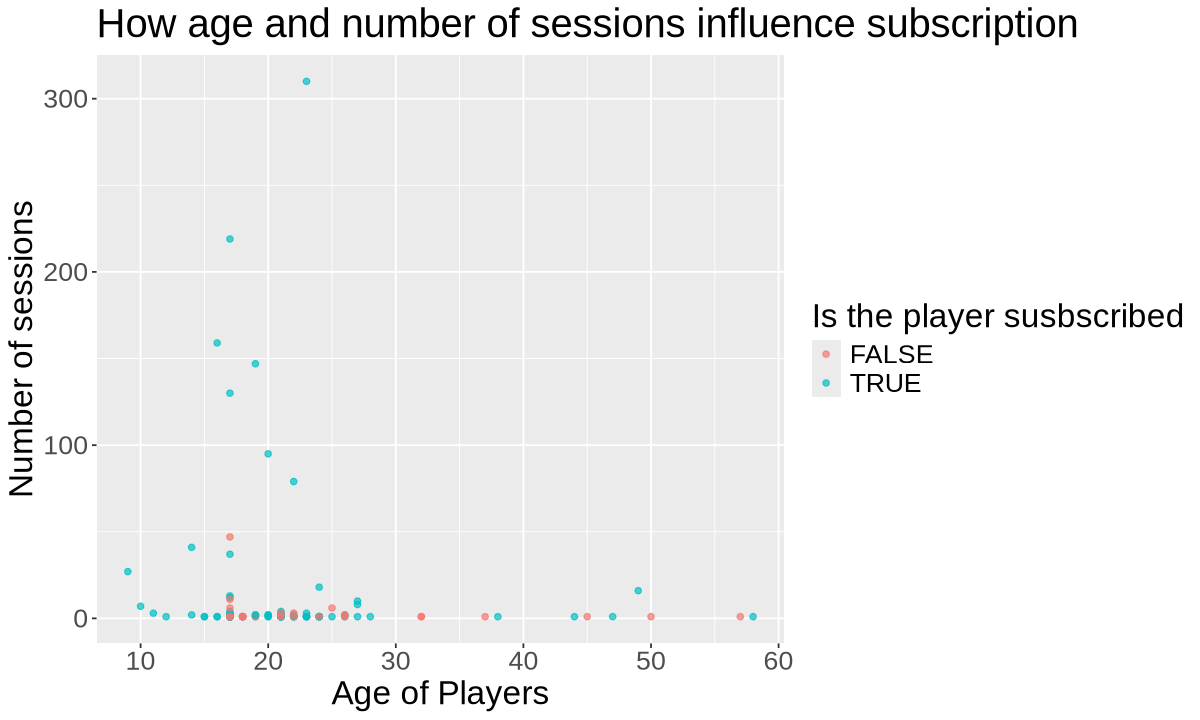

In [14]:
options(repr.plot.width=10, repr.plot.height=6)

plot_of_age_vs_subscription<- ggplot(minecraft_clean, aes(x = Age, y = session_count))+
geom_point(aes(colour = subscribe), alpha = 0.7)+ 
xlab("Age of Players")+ 
ylab("Number of sessions")+ 
ggtitle("How age and number of sessions influence subscription")+
labs(colour= "Is the player susbscribed")+
theme(text = element_text(size = 20))

plot_of_age_vs_subscription

**Figure 1.** The data was then plotted using age on the x-axis, session_count on the y-axis, and colouring the data points based on subscription status. The plot shows that there is not a linear relationship between the two variables and therefore using a K-NN classification model is most suitable for our analysis.  

## Renaming the Subscribe observations and balancing the data 

In [9]:
minecraft_clean <- minecraft_clean |>
  mutate(subscribe = factor(subscribe))

The above code changes the outcome variable to a factor. This is important because the K-NN classification models require that the output variable is a factor with clearly defined labels. The original output variables (TRUE and FALSE) are logical and therefore are not able to be used in the classification model unless changed.

## Splitting the data for training and analysis 

In [10]:
minecraft_split<- initial_split(minecraft_clean, prop = 0.75, strata = subscribe)
minecraft_training<- training(minecraft_split) 
minecraft_testing<- testing(minecraft_split)

The above code shows how we split the data into a training set and a testing set to use on the model. The training set will be used to train the model and determine the best K value and then the testing data is used to study the accuracy, specificity, and sensitivity of the model. 

## Making a recipe

In [11]:
minecraft_vfold<- vfold_cv(minecraft_training, v= 5, strata = subscribe)

Prior to creating a recipe a cross validation object is set. The cross validation improves the K-NN model and evaluates K values for the selection of the best K. 

In [12]:
minecraft_recipe<- recipe(subscribe ~ Age + session_count, data = minecraft_training)|> 
step_scale(Age, session_count)|> 
step_center(Age, session_count)|> 
step_upsample(subscribe)

minecraft_recipe



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 2



── Operations 

• Scaling for: Age and session_count

• Centering for: Age and session_count

• Up-sampling based on: subscribe



The above code creates a recipe for the K-NN model we are creating and evaluating. The first line of code specifies the output variable as well as the predictor variables Age and session_count. This is applied to the training data set. The data is also scaled, centered, and rebalanced in the code following in order to limit the bias in our model. Scaling the data is done as the model uses Euclidean distances, this process ensures that the standard deviation is 1 for both variables and limits a bias to the larger scale value. The data is centered in order to ensure all the variables have a mean of zero, this ensures that the distances measured are meaningful. Lastly, we rebalance the data for the variable subscribe in order to get an unbiased sensitivity. 

## Creating the K-NN classifier 

In [13]:
minecraft_knn_spec<- nearest_neighbor(weight_func = "rectangular", neighbors = tune())|> 
set_engine("kknn") |> 
set_mode("classification")
minecraft_knn_spec

K-Nearest Neighbor Model Specification (classification)

Main Arguments:
  neighbors = tune()
  weight_func = rectangular

Computational engine: kknn 


In [14]:
k_vals<- tibble(neighbors = seq(from = 1, to = 45, by=2))

knn_k_specification_results<- workflow()|> 
add_recipe(minecraft_recipe)|> 
add_model(minecraft_knn_spec)|>
tune_grid(resamples = minecraft_vfold, grid = k_vals)|> 
collect_metrics()


head(knn_k_specification_results)

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.5965256,5,0.01934357,Preprocessor1_Model01
1,roc_auc,binary,0.6089560,5,0.02295849,Preprocessor1_Model01
3,accuracy,binary,0.5315445,5,0.02463136,Preprocessor1_Model02
3,roc_auc,binary,0.6392857,5,0.02744174,Preprocessor1_Model02
5,accuracy,binary,0.4888545,5,0.02588613,Preprocessor1_Model03
5,roc_auc,binary,0.6404396,5,0.03219405,Preprocessor1_Model03


**Table 4.** The table above shows the K values tested, their respective accuracies and how well the model ranks the positive and negative cases. The mean column corresponds to the mean accuracy and roc_auc mean across the 5 fold cross validation and then the standard error is displayed as well. The roc_auc helps us understand the predictive power of our model by indicating how well the model separates between TRUE and FALSE classes at any possible threshold. 

## Graph of the K values 

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


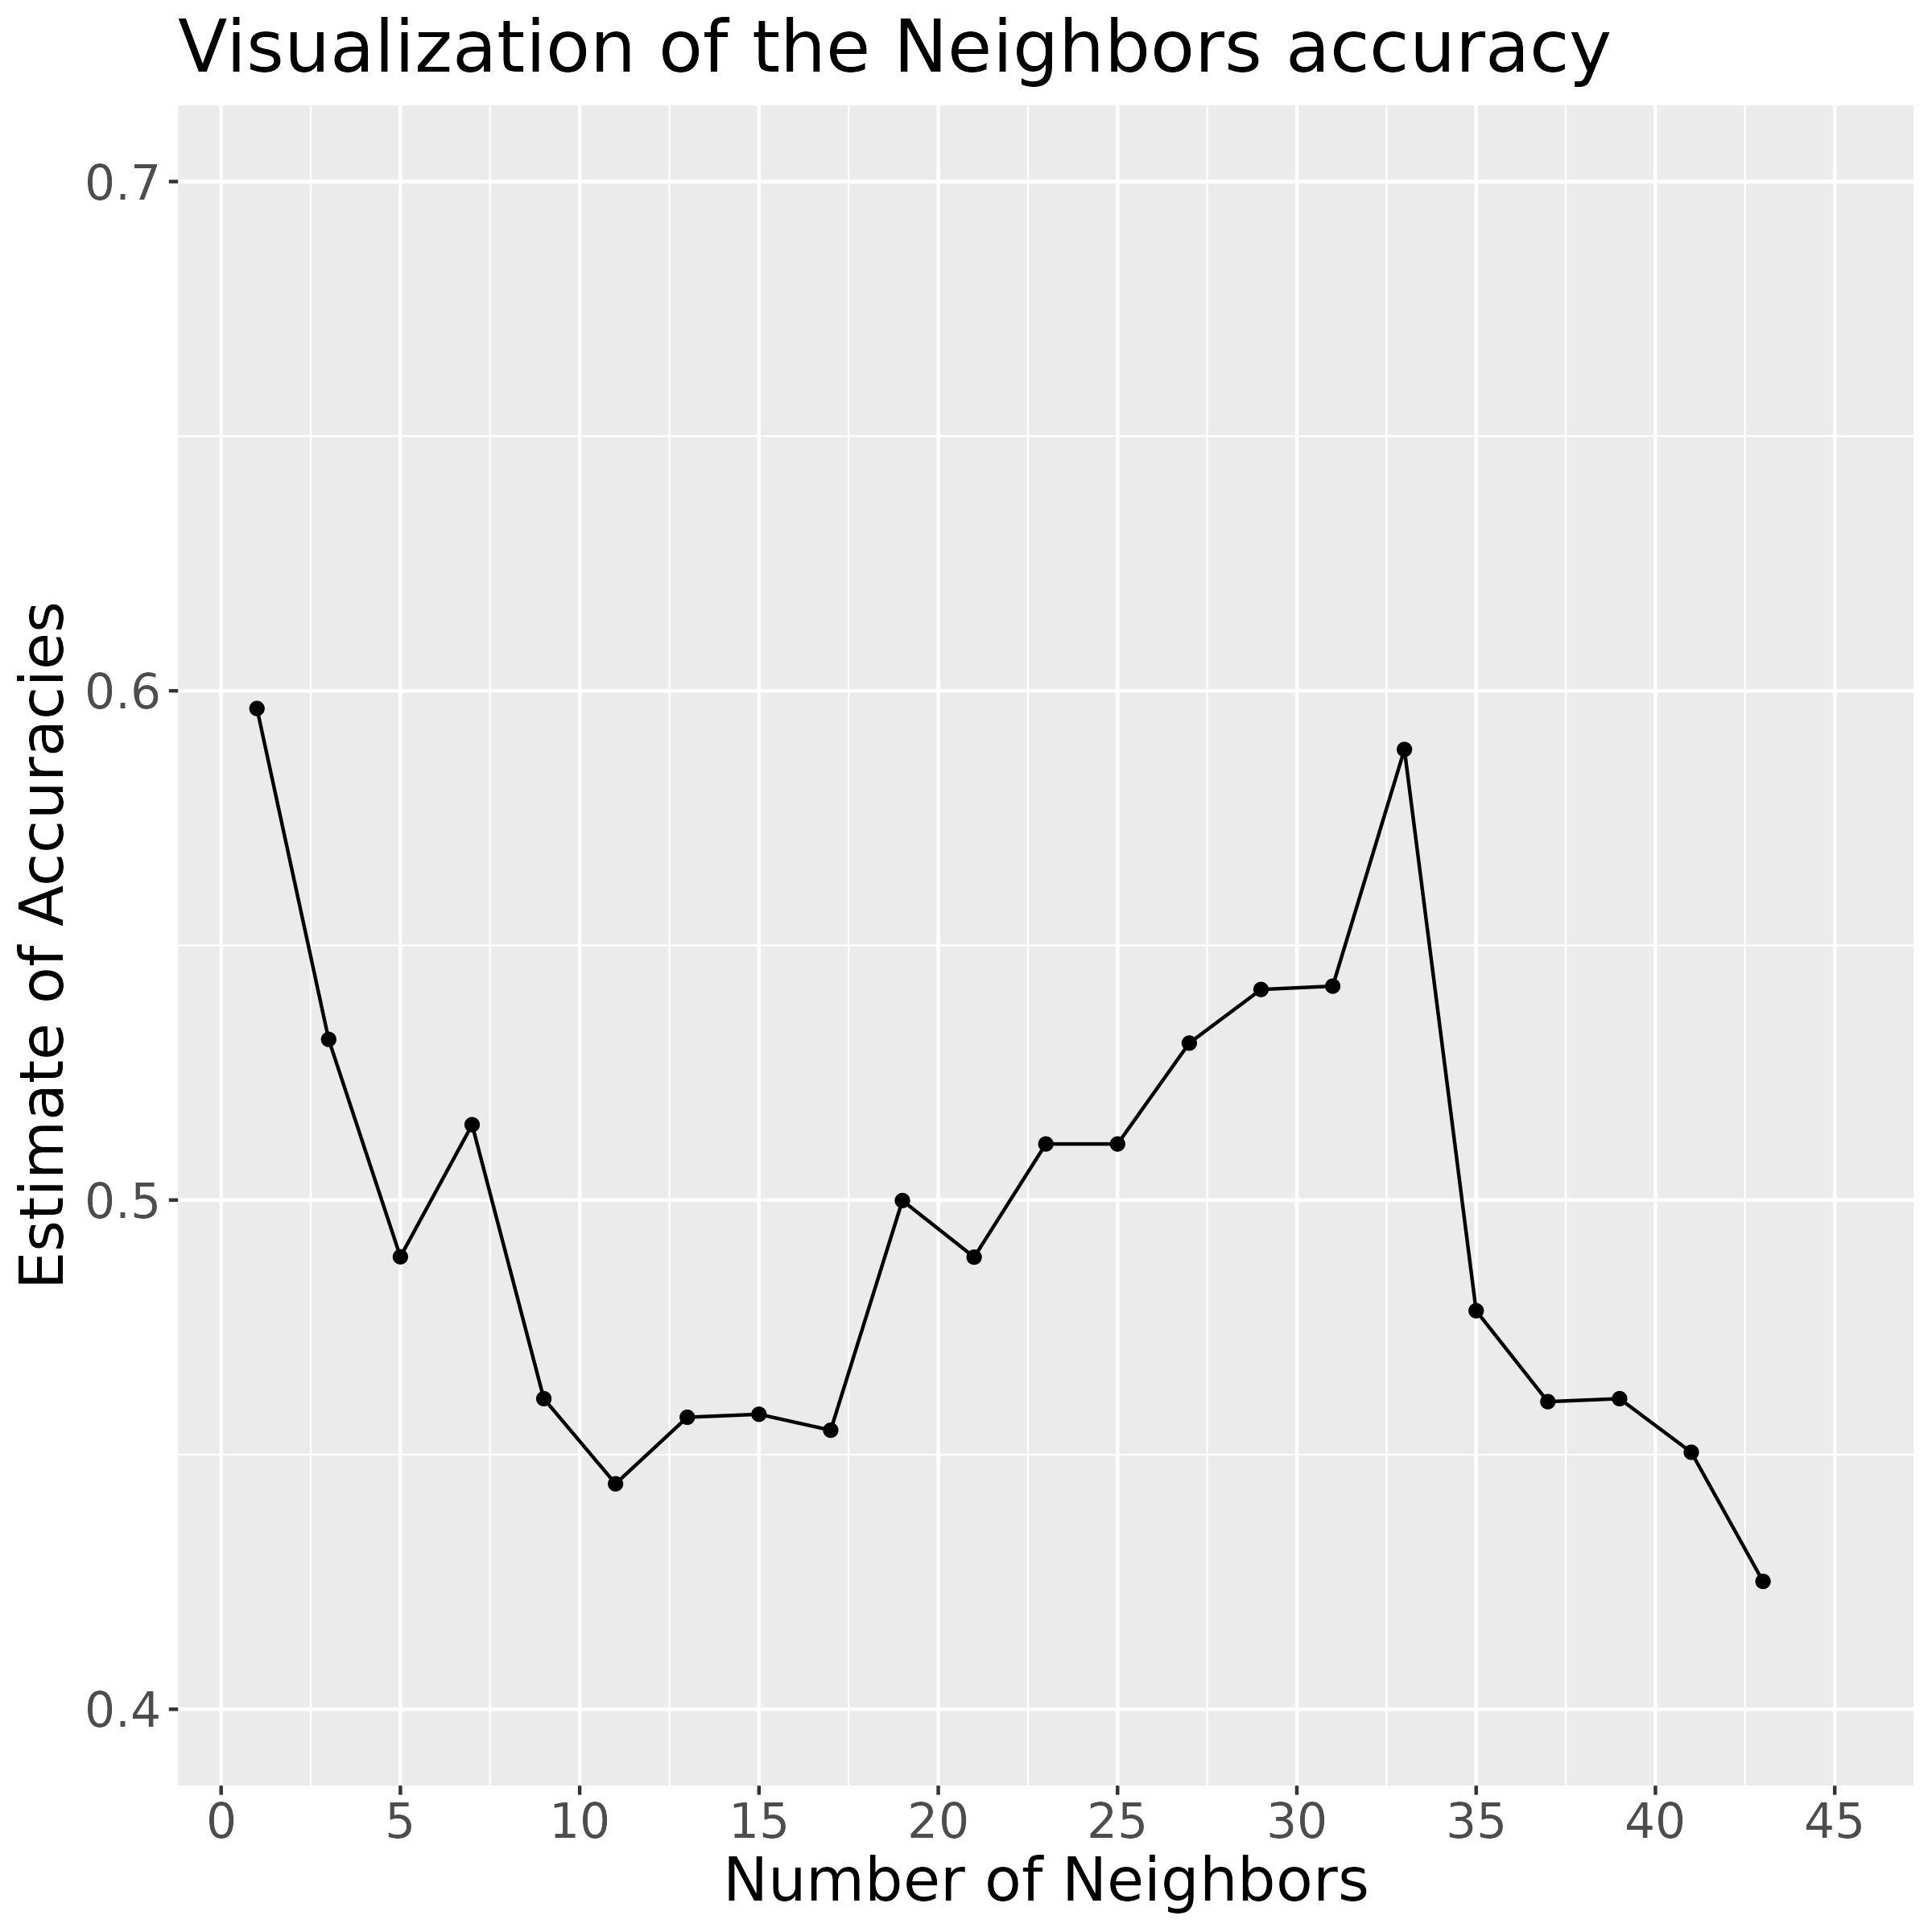

In [15]:
minecraft_accuracy<- knn_k_specification_results|> 
filter(.metric == "accuracy")

plot_of_k_values<- ggplot(minecraft_accuracy, aes(x = neighbors, y = mean))+ 
geom_point()+ 
geom_line()+ 
xlab("Number of Neighbors")+ 
ylab("Estimate of Accuracies")+ 
ggtitle("Visualization of the Neighbors accuracy")+
scale_x_continuous(breaks = seq(0, 55, by = 5)) +  
       scale_y_continuous(limits = c(0.4, 0.7))+
theme(text = element_text(size = 18))

ggsave("plot_of_k_values.png", plot = plot_of_k_values, width = 8, height = 8, dpi = 300)

IRdisplay::display_png(file = "plot_of_k_values.png")


**Figure 2.** The figure above graphs the number of K values versus the estimate of accuracy. From the graph it is observed that K = 1 has the highest accuracy and therefore is the best K value to use in the K-NN classification model. 

## Graph of roc auc

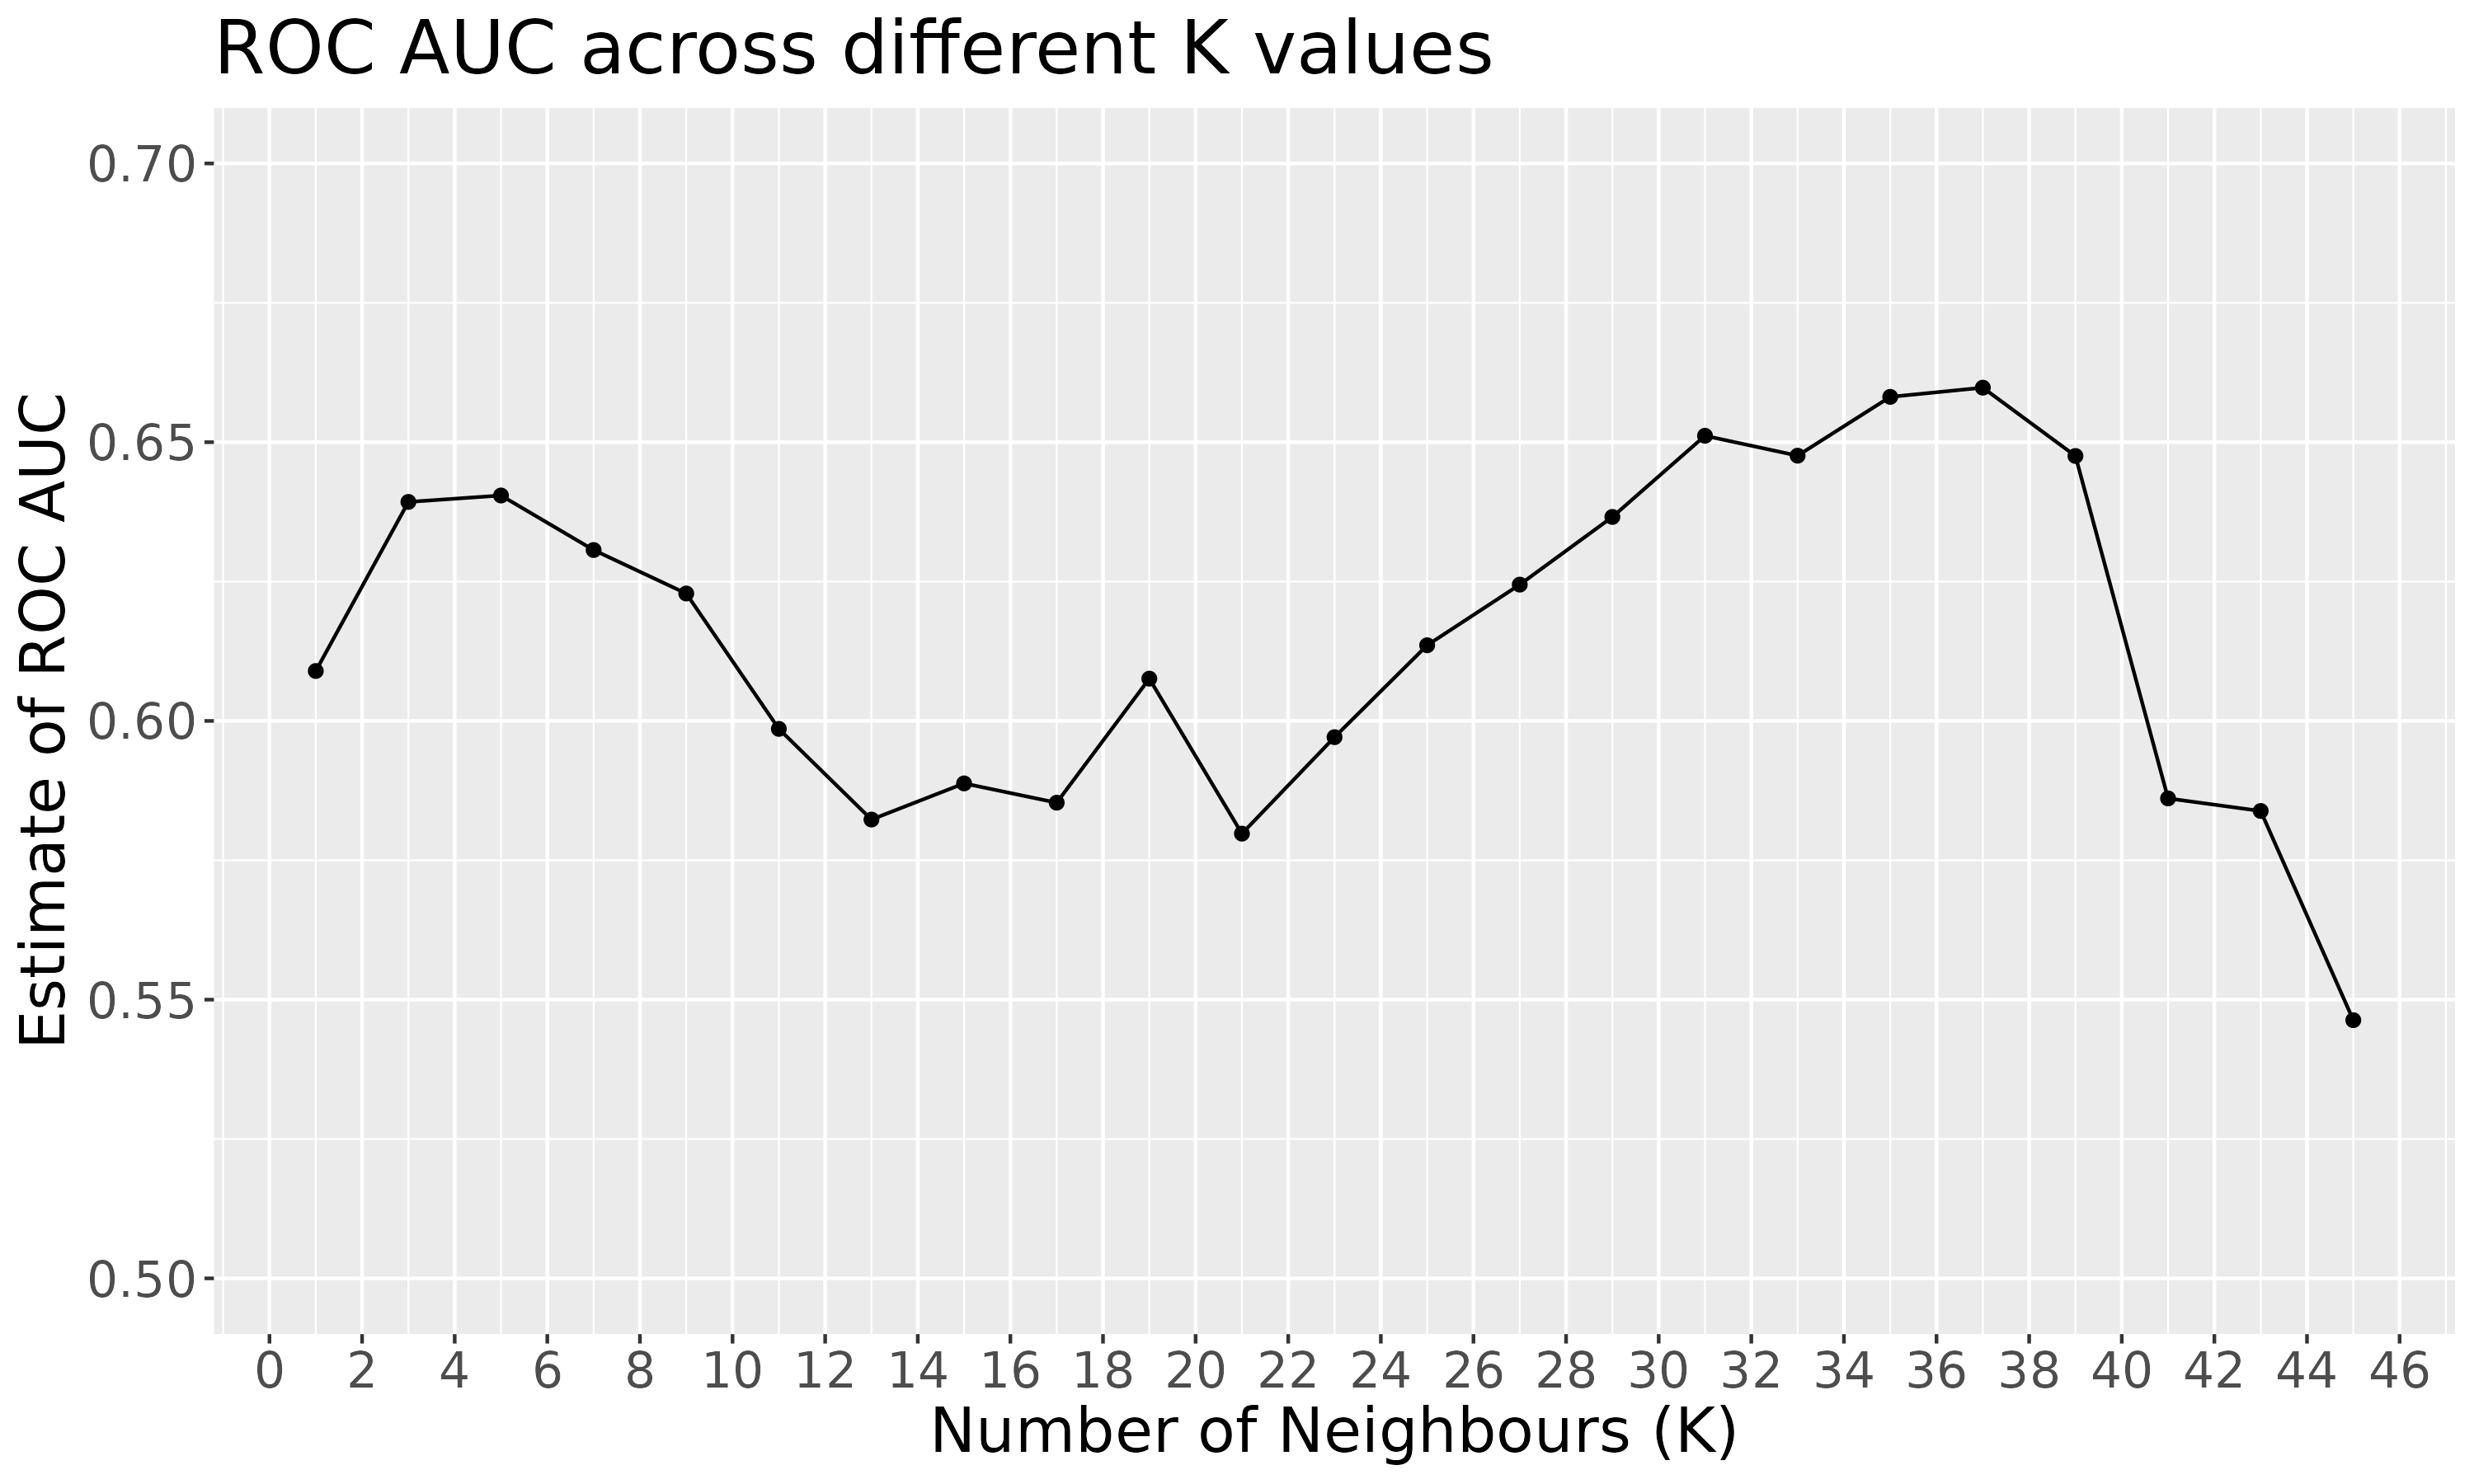

In [16]:
plot_of_roc_auc<- knn_k_specification_results|> 
filter(.metric == "roc_auc")|> 
ggplot(aes(x = neighbors, y = mean))+ 
geom_point()+ 
geom_line()+ 
xlab("Number of Neighbours (K)")+ 
ylab("Estimate of ROC AUC")+
ggtitle("ROC AUC across different K values")+
scale_x_continuous(breaks = seq(0, 50, by = 2)) +  
       scale_y_continuous(limits = c(0.5, 0.7))+
theme(text = element_text(size = 18))

ggsave("plot_of_roc_auc.png", plot = plot_of_roc_auc, width = 10, height = 6, dpi = 300)

IRdisplay::display_png(file = "plot_of_roc_auc.png")

**Figure 3.** The graph above is a plot of the K values against the mean of roc_auc. The graph displays the K values predictive power from distinguishing between TRUE and FALSE classes against any threshold. The values for this metric range from 0-1, where 1 is a perfect model and 0.5 indicates that the model is no better than random. Given this graph we could also try to use K = 38 for our model to see if it has better accuracy and kap on the testing data and then could plot the sensitivity and specificity.   

## Using the model on testing data 

In [17]:
minecraft_recipe_final<- recipe(subscribe ~ Age + session_count, data = minecraft_training)

minecraft_knn_spec_k<- nearest_neighbor(weight_func = "rectangular", neighbors = 1)|> 
set_engine("kknn")|> 
set_mode("classification")

minecraft_fit<- workflow()|> 
add_recipe(minecraft_recipe_final)|> 
add_model(minecraft_knn_spec_k)|> 
fit(data = minecraft_training)

minecraft_predictions<- predict(minecraft_fit, new_data = minecraft_testing) |> 
bind_cols(minecraft_testing)

minecraft_metrics<- minecraft_predictions|> 
metrics(truth = subscribe, estimate = .pred_class)


Here we use k = 1 to create our best model spec. We then combine this model spec with the same recipe as before into a workflow, and fit it to the training dataset to create the classifier. Lastly, we are applying this classifier to the testing dataset to get predictions on player subscription, binding these predictions to the testing data set so that accuracy of the predictions is evaluated against the "true" player subscription. 

In [18]:
minecraft_metrics

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.3548387
kap,binary,-0.2704918


**Table 5.** The accuracy tells us what proportions of predictions the model got correct, from our data we observe that the model is only correct 35% of the time. Additionally, kap (stands for Cohen's Kappa), represents the metric that indicates how good our model is compared to random guessing. The metric ranges from -1 to 1, where 1 indicates a perfect model and anything below 0 indicates that the model is worse than random guessing. As our kap value is -0.27 and we have an accuracy of 35% this indicates that our model doesn't perform well. 

## Precision

Here we compute the precision of our classifier on the test data. We consider the "TRUE" player subscription as our positive label. In other words, the classifier is caluclating this metric with respect to the "TRUE" subscription label.

In [19]:
minecraft_predictions |> pull(subscribe) |> levels()

[1] "FALSE" "TRUE"

In [20]:
minecraft_predictions |>
    precision(truth = subscribe, estimate = .pred_class, event_level = "first") 

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,0.125


**Table 6.** The precision of our classifier in prediciting TRUE player subscription was 0.125. This is a low precision and indicates that it was not good at predicting the positive labels in unseen data, and so such predictions are not reliable (subscribe = TRUE). 

## Recall

Following the same general method as precision, here we compute the recall of our classifier on the test data.

In [21]:
minecraft_predictions |>
    recall(truth = subscribe, estimate = .pred_class, event_level = "first")

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.25


**Table 7.** The recall of our classifier was 0.25, which is not high. This indicates that our classifier is not good at "finding" all of the TRUE player subscription labels in our testing data. 

## Confusion matrix

In [22]:
minecraft_conf_mat<- minecraft_predictions|> 
conf_mat(truth = subscribe, estimate = .pred_class)

minecraft_conf_mat

          Truth
Prediction FALSE TRUE
     FALSE     2   14
     TRUE      6    9

This confusion matrix shows what type of mistakes were made by our classifier. We see that it falsely classified 6 players as subscribed when they weren't, and 14 as not subscribed when they were. This is also shown by the heatmap below. 

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


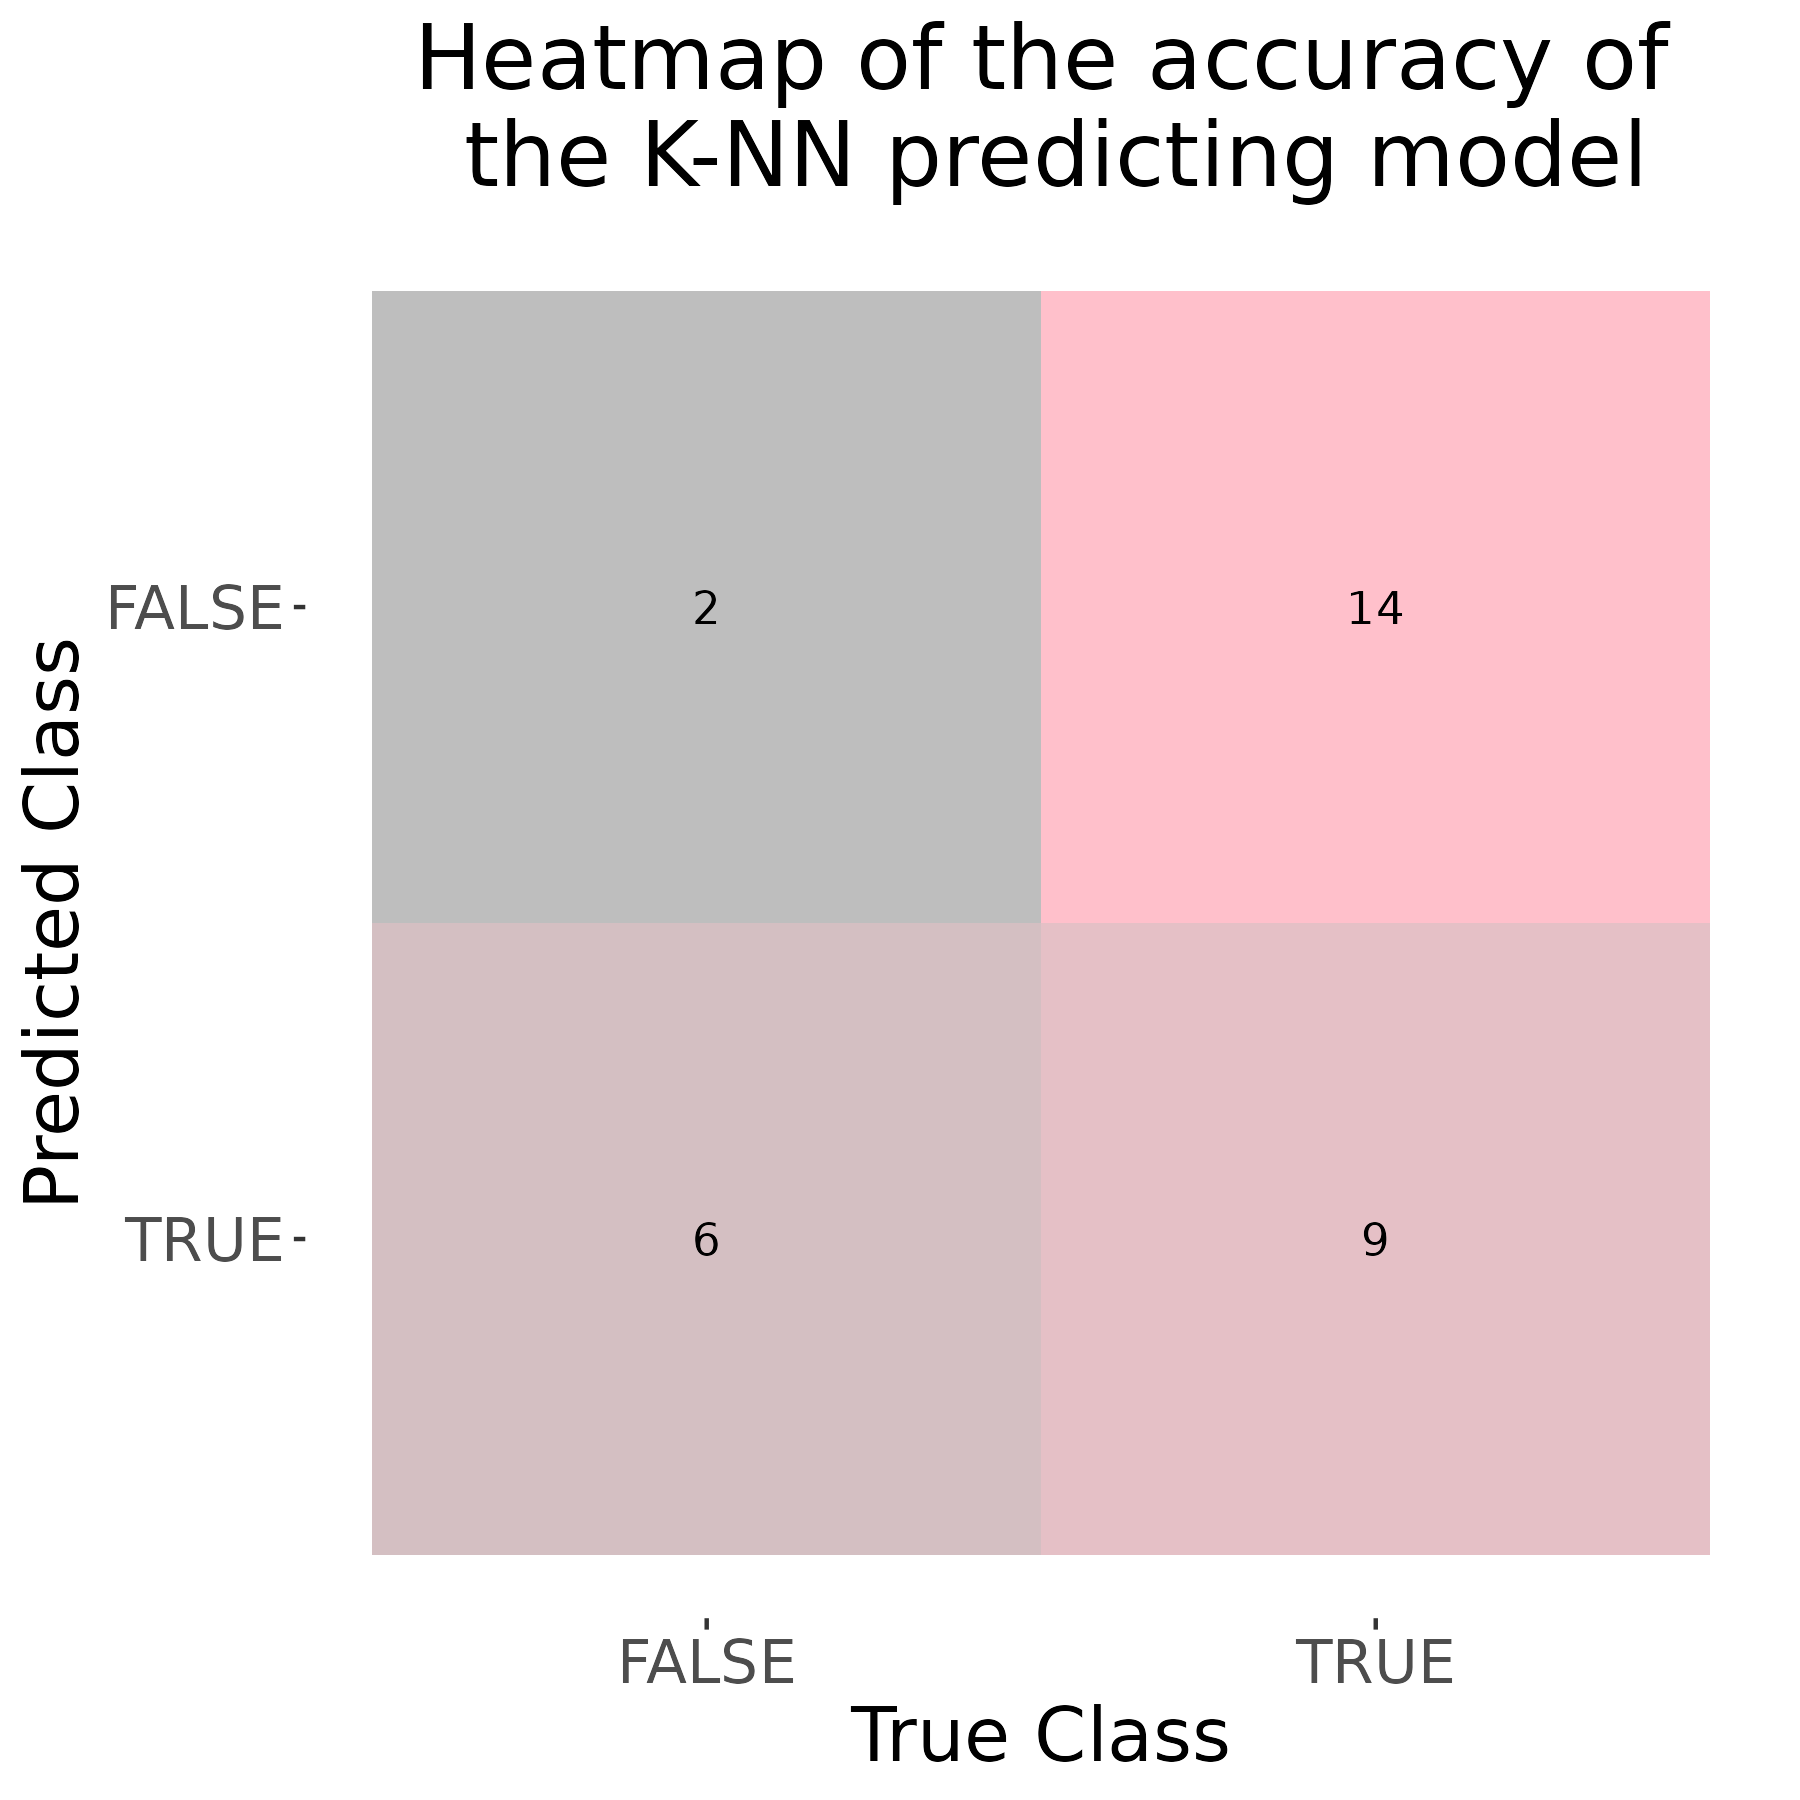

In [23]:
minecraft_conf_mat_heatmap<- minecraft_predictions|> 
conf_mat(truth = subscribe, estimate = .pred_class)|> 
autoplot(type = "heatmap")+ 
scale_fill_gradient(low = "grey", high = "pink")+ 
labs(x = "True Class", y= "Predicted Class", title = "Heatmap of the accuracy of\n the K-NN predicting model")+ 
theme(text = element_text(size = 18), 
    plot.title = element_text(hjust = 0.5))

ggsave("minecraft_conf_mat_heatmap.png", plot = minecraft_conf_mat_heatmap, width = 6, height = 6, dpi = 300)

IRdisplay::display_png(file = "minecraft_conf_mat_heatmap.png")

**Figure 4.** The heatmap above visualizes how well our model predicted on the testing data. From the visualization we can see that it generated 6 false positives, predicting subsription when the player was in fact not subscribed and 14 false negative, predicting not subscribed when the player was subscribed. 

# Discussion

The K-NN model analysis for predicting player subscription from age and session counts created a poor model with low accuracy, recall, and precision. These results are not surprising given the summary statistics from the data provided for analysis. Table 1 shows that the average and median ages are 21 and 19 years old, respectively. This indicates that the data collected was generally from late teens and early adults. Given the translation of information in our current society it is not surprising then that the data was imbalanced, with a greater proportion of subscribed individuals than those who were not subscribed. This is not surprising as the average age of players (21) is well versed in technology and commonly uses subscription methods to pass information along. Additionally, the small data set and poor results were expected as the data contained many users who never contributed to the session_count and therefore had to be removed from the data. This was done by combining the players data set and the sessions data set and then dropping the remaining NA observations.

The cleaned data was visualized for a linear relationship between the variables age and session_count as seen in Figure 1. The visualization showed no linear relationship and confirmed the use of K-NN classification for the following analysis. After splitting the data, creating a model for cross validation, scaling, centering, and rebalancing the data, the training data was used to identify the K value with the highest accuracy. The results were summarized in Table 4 and visualized in Figure 2. The model determined that K =1 has the highest accuracy with a mean accuracy of 0.596 determined from the 5 fold cross validation. 

The K value determined by the model suggested that the testing data, when ran through the model, would be overfit as data often influences the model too much when there is a low K value. Given this, we plotted the mean roc_auc values as the roc_auc  metric confirms the model's ability to separate the positive classes (TRUE) and negative classes (FALSE) against any threshold. When this method is used the results are plotted (sensitivity vs specificity) to quantize the model's discriminative power. The metric ranges from 0-1 where 1 is a perfect model and anything below 0.5 indicates the model performs worse than random guessing. As seen in Figure 3, the roc_auc metric suggests that K = 37 is the best k to use. However, this is a large K value and the model may underfit the data if used. Therefore the analysis on testing data was done using K = 1. 

Using K = 1 and running the testing data through the model quantified the accuracy and kap of our model as seen in Table 5. The accuracy of the model is 0.35 or 35% which is poor for a K-NN classification model. Additionally, the kap value is -0.27 indicating that the model is worse than random guessing. Alongside accuracy, we calculated the precision and recall of our classifier to further understand the types of mistakes the classifier was making. Both metrics were quite low; precision was 0.125 and recall was 0.25, as seen in Tables 6 and 7, respectively. The low precision indicates that few of the positive TRUE predictions made by the classifier were actually positive. The low recall indicates that our classifier is not good at "finding" all of the TRUE player subscription labels in our testing data. In addition to poor accuracy, these metrics show that our classifier cannot be trusted to make correct predictions on player subscription. The confusion matrix was visualized in Figure 4 as a heatmap and illustrates the mistakes our model commonly made. The heatmap shows that the model generated 6 false positives, 14 false negatives, correctly identified the false label 2 times and the true label 9 times. 

These results indicate that our model has poor performance and is not an effective predictor of player subscription. Our findings themselves don’t have many implications for the greater purpose of the PLAICraft study, but they may suggest what next steps not to take. Because the accuracy of our predictive model was subpar (therefore player age and session count shouldn’t be used to predict player subscription status), these variables also shouldn’t be used to answer the second part of our general question: “How do these features differ between various player types?” Aside from informing researchers what isn’t relevant, our findings have limited impact.

While our variables did not have significant findings for K = 1, researchers could use analysis with roc_auc to decide if the predictor variables we used still have any significance in predicting subscription. Evaluating the variables with K= 37 would indicate if the variables themselves are poor predictors for subscription or if using the accuracy metric for K determination was simply a poor choice. Additionally, the researchers may want to look into what variables can be measured that are more relevant to player subscription such as where the players heard of minecraft, or number of people they know who also play minecraft. It may also be worth evaluating the effectiveness of a different kind of classification algorithm.

**Link to GitHub repository:** https://github.com/chrispy-tacos/dsci-100-project.git